# Citi Bike 2025 EDA + Modeling v6

Builds on v5 with three additions:

- **GBFS capacity integration** — fetches live station capacity from the CitiBike GBFS API and merges it as a feature; also uses capacity to compute `utilization_ratio` (estimated bikes / capacity).
- **Fast feature engineering** — replaces slow `groupby().transform(lambda)` rolling calls with vectorized `shift + rolling`, converts `station_key` to `category` dtype before groupby, and gates the entire cell behind the parquet cache so it only runs once.
- **Capacity-aware EDA** — adds a capacity utilization plot and a capacity distribution chart.


## Roadmap

1. Load the trip, weather, and station lookup files.
2. Fetch **GBFS station capacity** and merge into station lookup.
3. Aggregate trips into a **station-hour** table.
4. Merge station metadata (with capacity) and hourly weather.
5. Engineer calendar, lag, rolling, cyclic, and next-hour target features — **fast vectorized path**.
6. Compute **capacity utilization** proxy.
7. Add **station clusters** (K-Means, enabled) and **weather PCA** (with scree plot).
8. Run EDA — including monthly seasonality and capacity utilization plots.
9. Compare models on **validation**, retrain on **train + validation**, evaluate once on **test**.
10. Report-ready diagnostics: dual-station plot, residual histogram, Q-Q plot, feature importance.


In [1]:
from pathlib import Path
import warnings
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.errors import EmptyDataError
from pandas.tseries.holiday import USFederalHolidayCalendar

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)


In [2]:
# --- Update these paths for your machine if needed ---
TRIP_CSV_PATH = Path("cleaned_combined.csv")
STATION_LOOKUP_PATH = Path("station_lookup.csv")
WEATHER_CSV_PATH = Path("nyc2025weatherdata.csv")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CHUNK_SIZE = 300_000
FORCE_REBUILD = False
TOP_N_STATIONS_FOR_MODEL = 50
TARGETS = ["departures_next_hour", "arrivals_next_hour", "net_flow_next_hour"]
PRIMARY_TARGET = "departures_next_hour"

USE_STATION_CLUSTERING = True
N_STATION_CLUSTERS = 8
USE_WEATHER_PCA = True
N_WEATHER_PCS = 3
RANDOM_STATE = 42

# GBFS capacity feed — live station metadata from CitiBike
# NOTE: This is a real-time feed; capacity values reflect today's station config.
# Historical capacity changes are not available via GBFS — acknowledge this in the report.
GBFS_STATION_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"


GBFS: fetched 2360 stations
  Active (capacity > 0): 2337
  Inactive (capacity = 0): 23
  Capacity range: 0 – 123


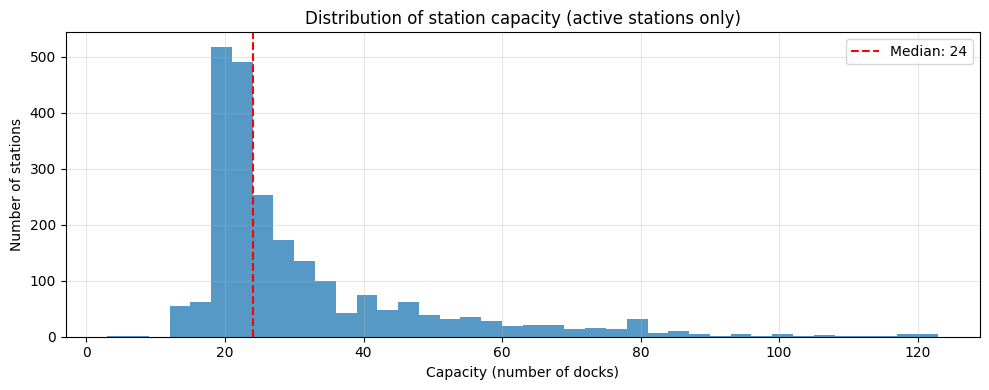

,capacity
count,2360.000000
mean,30.498729
std,17.524185
min,0.000000
25%,20.000000
50%,24.000000
75%,35.000000
max,123.000000


In [3]:
## Fetch GBFS station capacity
# The GBFS station_information feed provides current capacity (number of docks) per station.
# We merge this into the station lookup table so capacity is available as a feature.
# Stations with capacity=0 are inactive placeholders — we flag but do not drop them
# since they may still appear in historical trip data.

def fetch_gbfs_capacity(url, timeout=15):
    """Download station capacity from GBFS station_information feed."""
    try:
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        data = resp.json()
        stations = data["data"]["stations"]
        cap_df = pd.DataFrame([
            {
                "station_id": str(s["station_id"]),
                "capacity": int(s.get("capacity", 0)),
                "gbfs_name": s.get("name", ""),
            }
            for s in stations
        ])
        cap_df["station_id"] = cap_df["station_id"].astype("string")
        print(f"GBFS: fetched {len(cap_df)} stations")
        print(f"  Active (capacity > 0): {(cap_df['capacity'] > 0).sum()}")
        print(f"  Inactive (capacity = 0): {(cap_df['capacity'] == 0).sum()}")
        print(f"  Capacity range: {cap_df['capacity'].min()} – {cap_df['capacity'].max()}")
        return cap_df
    except Exception as e:
        print(f"WARNING: Could not fetch GBFS capacity ({e}). Proceeding without capacity feature.")
        return pd.DataFrame(columns=["station_id", "capacity", "gbfs_name"])

gbfs_capacity = fetch_gbfs_capacity(GBFS_STATION_INFO_URL)

# Quick capacity distribution preview
if len(gbfs_capacity) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    active = gbfs_capacity[gbfs_capacity["capacity"] > 0]["capacity"]
    ax.hist(active, bins=40, edgecolor="none", alpha=0.75)
    ax.set_title("Distribution of station capacity (active stations only)")
    ax.set_xlabel("Capacity (number of docks)")
    ax.set_ylabel("Number of stations")
    ax.axvline(active.median(), color="red", linestyle="--", label=f"Median: {active.median():.0f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    display(gbfs_capacity.describe())


## Safe schema previews

In [4]:
preview = pd.read_csv(TRIP_CSV_PATH, nrows=5)
preview.columns = preview.columns.str.strip().str.lower()
trip_columns = preview.columns.tolist()

print("Trip columns:")
print(trip_columns)
display(preview.head())

if STATION_LOOKUP_PATH.exists():
    station_lookup_preview = pd.read_csv(STATION_LOOKUP_PATH, nrows=5)
    station_lookup_preview.columns = station_lookup_preview.columns.str.strip().str.lower()
    display(station_lookup_preview.head())
else:
    print("station_lookup.csv not found. The notebook will continue with a minimal station table.")

weather_preview = pd.read_csv(WEATHER_CSV_PATH, nrows=5)
weather_preview.columns = weather_preview.columns.str.strip()
display(weather_preview.head())


Trip columns:
['started_at', 'ended_at', 'start_station_id', 'end_station_id', 'start_station_name', 'end_station_name', 'rideable_type', 'member_casual']


,started_at,ended_at,start_station_id,end_station_id,start_station_name,end_station_name,rideable_type,member_casual
0,2025-01-01 14:52:26,2025-01-01 14:59:53,6182.02,5746.02,W 20 St & 7 Ave,E 10 St & 2 Ave,electric_bike,casual
1,2025-01-10 05:03:13,2025-01-10 05:13:13,6182.02,6004.07,W 20 St & 7 Ave,E 25 St & 1 Ave,classic_bike,member
2,2025-01-13 13:40:17,2025-01-13 13:47:05,5238.05,5137.11,St James Pl & Oliver St,Fulton St & William St,classic_bike,member
3,2025-01-10 08:29:16,2025-01-10 08:34:49,5238.05,5137.11,St James Pl & Oliver St,Fulton St & William St,electric_bike,member
4,2025-01-11 18:59:48,2025-01-11 19:13:21,6197.08,5414.06,E 33 St & 1 Ave,Allen St & Rivington St,electric_bike,member


,station_id,station_name,lat,lng
0,1234.56,Morgan HCT Charging,40.708948,-73.932777
1,190 Morgan,190 Morgan,40.711072,-73.932096
2,1964.01,101 St & Fort Hamilton Pkwy,40.611240,-74.032820
3,2009.04,Shore Rd & 4 Ave,40.611500,-74.035130
4,2042.01,4 Ave & 99 St,40.613270,-74.033150


,location_id,time,temperature_2m (°F),precipitation (inch),rain (inch),snowfall (inch),snow_depth (ft),wind_speed_10m (mp/h),soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_2m (%),dew_point_2m (°F),apparent_temperature (°F),wind_gusts_10m (mp/h),wind_direction_10m (°)
0,0,2025-01-01T00:00,45.6,0.146,0.146,0.0,0.0,10.7,44.3,43.7,94,44.0,39.5,22.4,91
1,0,2025-01-01T01:00,46.8,0.035,0.035,0.0,0.0,9.3,44.6,43.7,96,45.8,41.8,23.7,92
2,0,2025-01-01T02:00,47.6,0.000,0.000,0.0,0.0,4.8,45.0,43.7,97,46.7,44.7,18.1,109
3,0,2025-01-01T03:00,48.0,0.000,0.000,0.0,0.0,5.4,45.3,43.8,99,47.7,45.1,10.1,171
4,0,2025-01-01T04:00,48.0,0.000,0.000,0.0,0.0,5.5,45.7,43.9,98,47.6,45.1,10.3,223


## Detect which station columns are available

In [5]:
def pick_station_columns(columns):
    columns = set(columns)

    if "start_station_id" in columns and "end_station_id" in columns:
        return "start_station_id", "end_station_id", "id"
    if "start_station_name" in columns and "end_station_name" in columns:
        return "start_station_name", "end_station_name", "name"

    raise ValueError(
        "Could not find usable station columns. Expected start/end station ids or names."
    )

START_KEY_COL, END_KEY_COL, KEY_MODE = pick_station_columns(trip_columns)
print("Using start key column:", START_KEY_COL)
print("Using end key column:", END_KEY_COL)
print("Key mode:", KEY_MODE)


Using start key column: start_station_id
Using end key column: end_station_id
Key mode: id


## Station lookup preparation

If `station_lookup.csv` is missing, the notebook will still run with a minimal `station_key` table.
That means the main forecasting pipeline still works, but location-based clustering will rely only on activity features.


In [6]:
def prepare_station_lookup(station_lookup_path, key_mode="id", gbfs_cap_df=None):
    if not station_lookup_path.exists():
        print("station_lookup.csv not found. Proceeding without station metadata.")
        return None

    station_lookup = pd.read_csv(station_lookup_path)
    station_lookup.columns = station_lookup.columns.str.strip().str.lower()

    if key_mode == "id":
        if "station_id" not in station_lookup.columns:
            raise ValueError("station_lookup.csv must contain station_id when using station ids.")
        station_lookup = station_lookup.rename(columns={"station_id": "station_key"})
    else:
        if "station_name" not in station_lookup.columns:
            raise ValueError("station_lookup.csv must contain station_name when using station names.")
        station_lookup = station_lookup.rename(columns={"station_name": "station_key"})

    station_lookup["station_key"] = station_lookup["station_key"].astype("string")
    if "station_name" not in station_lookup.columns:
        station_lookup["station_name"] = station_lookup["station_key"]

    keep_cols = [c for c in ["station_key", "station_name", "lat", "lng"] if c in station_lookup.columns]
    station_lookup = station_lookup[keep_cols].drop_duplicates(subset=["station_key"])

    # Merge GBFS capacity if available
    if gbfs_cap_df is not None and len(gbfs_cap_df) > 0:
        cap_merge = gbfs_cap_df[["station_id", "capacity"]].rename(columns={"station_id": "station_key"})
        cap_merge["station_key"] = cap_merge["station_key"].astype("string")
        station_lookup = station_lookup.merge(cap_merge, on="station_key", how="left")
        n_matched = station_lookup["capacity"].notna().sum()
        print(f"Capacity matched: {n_matched}/{len(station_lookup)} stations ({n_matched/len(station_lookup)*100:.1f}%)")
        # Fill unmatched with median capacity so it doesn't introduce NaNs into the model
        median_cap = station_lookup["capacity"].median()
        station_lookup["capacity"] = station_lookup["capacity"].fillna(median_cap).astype("float32")
        station_lookup["is_active_station"] = (station_lookup["capacity"] > 0).astype("int8")
    else:
        print("No GBFS capacity data — 'capacity' feature will not be available.")

    return station_lookup


## Chunked station-hour aggregation

This is the heaviest preprocessing step.

For each trip chunk, we count:
- departures by `(start station, start hour)`
- arrivals by `(end station, end hour)`

Then we build a station-hour table with:
- `departures`
- `arrivals`
- `net_flow = arrivals - departures`
- `total_activity = arrivals + departures`

This version also fixes a counting bug from the starter notebook by making sure each chunk is added **once** to the running totals.


In [7]:
def save_table_with_fallback(df, preferred_path):
    preferred_path = Path(preferred_path)
    try:
        df.to_parquet(preferred_path, index=False)
        return preferred_path
    except Exception as exc:
        fallback_path = preferred_path.with_suffix(".csv")
        print(f"Parquet save failed ({exc}). Saving CSV cache instead: {fallback_path}")
        df.to_csv(fallback_path, index=False)
        return fallback_path


def load_cached_table(preferred_path):
    preferred_path = Path(preferred_path)

    if preferred_path.exists():
        try:
            return pd.read_parquet(preferred_path)
        except Exception as exc:
            print(f"Failed to read parquet cache {preferred_path}: {exc}")

    csv_fallback = preferred_path.with_suffix(".csv")
    if csv_fallback.exists():
        try:
            print(f"Loading cached table from {csv_fallback}")
            return pd.read_csv(csv_fallback, parse_dates=["hour"])
        except EmptyDataError:
            print(f"CSV cache is empty: {csv_fallback}")
            return None
        except Exception as exc:
            print(f"Failed to read CSV fallback {csv_fallback}: {exc}")
            return None

    return None


def aggregate_station_hour(
    trip_csv_path,
    trip_columns,
    start_key_col,
    end_key_col,
    chunksize=300_000,
    cache_path=None,
    force_rebuild=False,
):
    if cache_path is not None and not force_rebuild:
        cached = load_cached_table(cache_path)
        if cached is not None:
            return cached

    base_usecols = ["started_at", "ended_at", start_key_col, end_key_col]
    usecols = [c for c in base_usecols if c in trip_columns]
    dtype_map = {start_key_col: "string", end_key_col: "string"}

    departures = pd.Series(dtype="float64")
    arrivals = pd.Series(dtype="float64")

    reader = pd.read_csv(
        trip_csv_path,
        usecols=usecols,
        dtype=dtype_map,
        chunksize=chunksize,
        low_memory=True,
    )

    for chunk_idx, chunk in enumerate(reader, start=1):
        chunk.columns = chunk.columns.str.strip().str.lower()
        chunk = chunk.dropna(subset=["started_at", "ended_at", start_key_col, end_key_col]).copy()

        chunk["started_at"] = pd.to_datetime(chunk["started_at"], errors="coerce")
        chunk["ended_at"] = pd.to_datetime(chunk["ended_at"], errors="coerce")
        chunk = chunk.dropna(subset=["started_at", "ended_at"]).copy()

        chunk[start_key_col] = chunk[start_key_col].astype("string")
        chunk[end_key_col] = chunk[end_key_col].astype("string")

        chunk["start_hour"] = chunk["started_at"].dt.floor("h")
        chunk["end_hour"] = chunk["ended_at"].dt.floor("h")

        dep = chunk.groupby([start_key_col, "start_hour"]).size().astype("float64")
        arr = chunk.groupby([end_key_col, "end_hour"]).size().astype("float64")

        departures = dep if departures.empty else departures.add(dep, fill_value=0)
        arrivals = arr if arrivals.empty else arrivals.add(arr, fill_value=0)

        if chunk_idx % 5 == 0:
            print(f"Processed {chunk_idx} chunks...")

    departures = departures.rename("departures").reset_index()
    departures = departures.rename(columns={start_key_col: "station_key", "start_hour": "hour"})

    arrivals = arrivals.rename("arrivals").reset_index()
    arrivals = arrivals.rename(columns={end_key_col: "station_key", "end_hour": "hour"})

    station_hour = departures.merge(arrivals, on=["station_key", "hour"], how="outer")
    station_hour["departures"] = station_hour["departures"].fillna(0).astype("int32")
    station_hour["arrivals"] = station_hour["arrivals"].fillna(0).astype("int32")
    station_hour["station_key"] = station_hour["station_key"].astype("string")
    station_hour["hour"] = pd.to_datetime(station_hour["hour"])

    station_hour["net_flow"] = station_hour["arrivals"] - station_hour["departures"]
    station_hour["total_activity"] = station_hour["arrivals"] + station_hour["departures"]
    station_hour = station_hour.sort_values(["station_key", "hour"]).reset_index(drop=True)

    if cache_path is not None:
        saved_to = save_table_with_fallback(station_hour, cache_path)
        print(f"Saved station-hour cache to {saved_to}")

    return station_hour


In [8]:
station_hour_cache = OUTPUT_DIR / "station_hour_2025_v2.parquet"
station_hour = aggregate_station_hour(
    trip_csv_path=TRIP_CSV_PATH,
    trip_columns=trip_columns,
    start_key_col=START_KEY_COL,
    end_key_col=END_KEY_COL,
    chunksize=CHUNK_SIZE,
    cache_path=station_hour_cache,
    force_rebuild=FORCE_REBUILD,
)

station_lookup = prepare_station_lookup(STATION_LOOKUP_PATH, key_mode=KEY_MODE, gbfs_cap_df=gbfs_capacity)
if station_lookup is None:
    station_lookup = pd.DataFrame({"station_key": station_hour["station_key"].drop_duplicates().astype("string")})

print(station_hour.shape)
print("Unique stations:", station_hour["station_key"].nunique())
print("Hour range:", station_hour["hour"].min(), "to", station_hour["hour"].max())
print("Total departures:", int(station_hour["departures"].sum()))
print("Total arrivals:", int(station_hour["arrivals"].sum()))
display(station_hour.head())


Capacity matched: 0/2428 stations (0.0%)
(11966828, 6)
Unique stations: 2428
Hour range: 2024-12-31 12:00:00 to 2025-12-31 23:00:00
Total departures: 45623754
Total arrivals: 45623754


,station_key,hour,departures,arrivals,net_flow,total_activity
0,1234.56,2025-06-18 22:00:00,0,1,1,1
1,1234.56,2025-06-18 23:00:00,1,1,0,2
2,1234.56,2025-06-19 23:00:00,1,0,-1,1
3,1234.56,2025-06-20 09:00:00,1,1,0,2
4,1234.56,2025-06-20 12:00:00,1,1,0,2


## Merge station metadata and hourly weather

In [9]:
def load_weather(weather_csv_path):
    weather = pd.read_csv(weather_csv_path)

    rename_map = {
        "time": "hour",
        "temperature_2m (degF)": "temperature_f",
        "temperature_2m (°F)": "temperature_f",
        "precipitation (inch)": "precipitation_in",
        "rain (inch)": "rain_in",
        "snowfall (inch)": "snowfall_in",
        "snow_depth (ft)": "snow_depth_ft",
        "wind_speed_10m (mp/h)": "wind_speed_mph",
        "relative_humidity_2m (%)": "relative_humidity_pct",
        "dew_point_2m (degF)": "dew_point_f",
        "dew_point_2m (°F)": "dew_point_f",
        "apparent_temperature (degF)": "apparent_temperature_f",
        "apparent_temperature (°F)": "apparent_temperature_f",
        "wind_gusts_10m (mp/h)": "wind_gusts_mph",
        "wind_direction_10m (deg)": "wind_direction_deg",
        "wind_direction_10m (°)": "wind_direction_deg",
        "cloud_cover (%)": "cloud_cover_pct",
        "surface_pressure (hPa)": "surface_pressure_hpa",
        "visibility (ft)": "visibility_ft",
    }

    weather = weather.rename(columns=rename_map)
    weather.columns = [c.strip() for c in weather.columns]

    if "hour" not in weather.columns:
        raise ValueError("Could not find a time/hour column in the weather CSV.")

    weather["hour"] = pd.to_datetime(weather["hour"], errors="coerce")
    weather = weather.dropna(subset=["hour"]).copy()
    weather = weather.sort_values("hour").drop_duplicates(subset=["hour"])
    return weather


weather = load_weather(WEATHER_CSV_PATH)
station_hour_enriched = station_hour.merge(station_lookup, on="station_key", how="left")
station_hour_weather = station_hour_enriched.merge(weather, on="hour", how="left")

merged_cache = OUTPUT_DIR / "station_hour_weather_2025_v2.parquet"
save_table_with_fallback(station_hour_weather, merged_cache)

print(station_hour_weather.shape)
display(station_hour_weather.head())


(11966828, 25)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,capacity,is_active_station,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg
0,1234.56,2025-06-18 22:00:00,0,1,1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0
1,1234.56,2025-06-18 23:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0
3,1234.56,2025-06-20 09:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0
4,1234.56,2025-06-20 12:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0


## Feature engineering

This section adds:
- calendar features,
- **cyclic (sin/cos) encoding** for `hour_of_day` and `day_of_week`,
- holiday and commute flags,
- lag and rolling features by station,
- next-hour targets,
- simple precipitation / snow indicators.

**Note on raw current-hour counts:** `departures`, `arrivals`, `net_flow`, and `total_activity`
are excluded from the model feature set. Only their lag and rolling versions are used,
which keeps the inference setup unambiguous — at prediction time the current hour is not yet complete.


In [10]:
def engineer_features(df):
    # Convert station_key to category FIRST — makes all groupby operations much faster
    df = df.copy()
    df["station_key"] = df["station_key"].astype("category")
    df = df.sort_values(["station_key", "hour"]).reset_index(drop=True)

    df["hour_of_day"] = df["hour"].dt.hour
    df["day_of_week"] = df["hour"].dt.dayofweek
    df["month"] = df["hour"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype("int8")
    df["is_rush_hour"] = df["hour_of_day"].isin([7, 8, 9, 16, 17, 18]).astype("int8")
    df["is_commute_peak"] = ((df["is_weekend"] == 0) & (df["is_rush_hour"] == 1)).astype("int8")
    df["is_overnight"] = df["hour_of_day"].isin([0, 1, 2, 3, 4, 5]).astype("int8")

    # Cyclic encoding — prevents the model from treating hour 23 as "far" from hour 0
    df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df["hour"].min().normalize(), end=df["hour"].max().normalize())
    df["is_holiday"] = df["hour"].dt.normalize().isin(holidays).astype("int8")

    if "precipitation_in" in df.columns:
        df["is_precipitating"] = (df["precipitation_in"].fillna(0) > 0).astype("int8")
        df["heavy_precip_flag"] = (df["precipitation_in"].fillna(0) >= 0.10).astype("int8")
    else:
        df["is_precipitating"] = np.int8(0)
        df["heavy_precip_flag"] = np.int8(0)

    if "rain_in" in df.columns:
        df["is_raining"] = (df["rain_in"].fillna(0) > 0).astype("int8")
    else:
        df["is_raining"] = np.int8(0)

    if "snowfall_in" in df.columns:
        df["is_snowing"] = (df["snowfall_in"].fillna(0) > 0).astype("int8")
    else:
        df["is_snowing"] = np.int8(0)

    # ── Fast vectorized lag/rolling ───────────────────────────────────────────
    # Using category dtype + explicit shift+rolling avoids slow lambda transforms.
    # Shift is applied BEFORE rolling so no future data leaks into the window.
    base_cols = ["departures", "arrivals", "net_flow", "total_activity"]
    grp = df.groupby("station_key", observed=True, sort=False)

    for col in base_cols:
        s = grp[col]
        df[f"{col}_lag_1"]  = s.shift(1)
        df[f"{col}_lag_2"]  = s.shift(2)
        df[f"{col}_lag_24"] = s.shift(24)

        # Rolling on the already-shifted series — avoids lambda overhead
        shifted = s.shift(1)
        df[f"{col}_roll_3"]  = shifted.groupby(df["station_key"], observed=True).transform(
            lambda x: x.rolling(3,  min_periods=1).mean()
        )
        df[f"{col}_roll_24"] = shifted.groupby(df["station_key"], observed=True).transform(
            lambda x: x.rolling(24, min_periods=1).mean()
        )

    df["departures_next_hour"] = grp["departures"].shift(-1)
    df["arrivals_next_hour"]   = grp["arrivals"].shift(-1)
    df["net_flow_next_hour"]   = grp["net_flow"].shift(-1)

    return df


# ── Cache gate — only run engineer_features if the parquet cache is missing ──
feature_cache = OUTPUT_DIR / "feature_df_model_ready_2025_v6.parquet"

if not FORCE_REBUILD and feature_cache.exists():
    print("Loading feature_df from cache...")
    feature_df = pd.read_parquet(feature_cache)
    feature_df["station_key"] = feature_df["station_key"].astype("category")
    print(f"Loaded: {feature_df.shape}")
else:
    print("Building feature_df (this runs once, then caches)...")
    feature_df = engineer_features(station_hour_weather)
    save_table_with_fallback(feature_df, feature_cache)
    print(f"Done: {feature_df.shape}")

display(feature_df.head())


Loading feature_df from cache...
Loaded: (11966828, 66)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,capacity,is_active_station,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,utilization_ratio,utilization_ratio_lag_1
0,1234.56,2025-06-18 22:00:00,0,1,1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-5.000000e-01,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN
1,1234.56,2025-06-18 23:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-2.588190e-01,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.000000,0.000000,1.0,NaN,NaN,1.000000,1.000000,1.0,NaN,NaN,1.000000,1.0,1.0,NaN,NaN,1.000000,1.000000,1.0,0.0,-1.0,NaN,NaN
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-2.588190e-01,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.500000,0.500000,1.0,1.0,NaN,1.000000,1.000000,0.0,1.0,NaN,0.500000,0.5,2.0,1.0,NaN,1.500000,1.500000,1.0,1.0,0.0,NaN,NaN
3,1234.56,2025-06-20 09:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0,9,4,6,0,1,1,0,7.071068e-01,-0.707107,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,0.666667,0.666667,0.0,1.0,NaN,0.666667,0.666667,-1.0,0.0,NaN,0.000000,0.0,1.0,2.0,NaN,1.333333,1.333333,1.0,1.0,0.0,NaN,NaN
4,1234.56,2025-06-20 12:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0,12,4,6,0,0,0,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,1.000000,0.750000,1.0,0.0,NaN,0.666667,0.750000,0.0,-1.0,NaN,-0.333333,0.0,2.0,1.0,NaN,1.666667,1.500000,1.0,1.0,0.0,NaN,NaN


## Capacity utilization proxy

Using GBFS capacity + cumulative net flow, we estimate how "full" each station is at each hour.
This converts the flow prediction problem into an availability proxy — closer to the project's original goal.

**Key assumption:** We don't know the true starting bike count, so we initialize each station each day
at 50% capacity. Cumulative net flow within each day then shifts the estimate up or down.
Values are clipped to [0, capacity] since bike counts can't be negative or exceed capacity.


Utilization ratio stats:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: utilization_ratio, dtype: float64

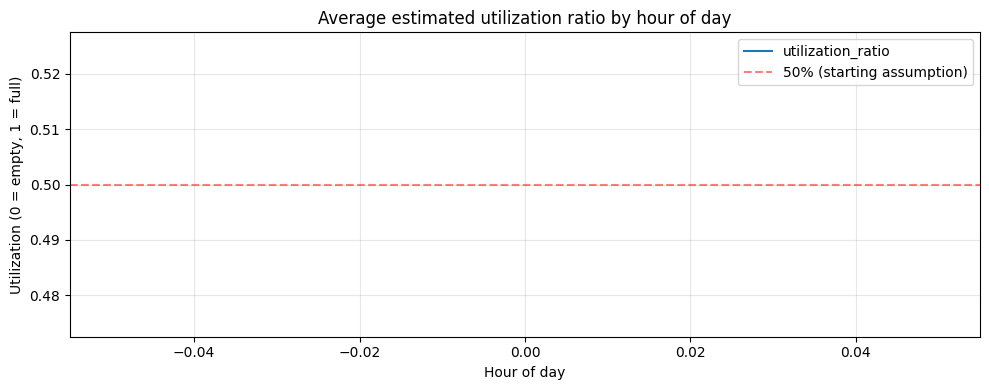

In [11]:
def add_capacity_utilization(df):
    """
    Estimate hourly bike count per station as a fraction of capacity.
    Requires 'capacity' column in df (from GBFS merge).
    """
    if "capacity" not in df.columns:
        print("'capacity' column not found — skipping utilization feature.")
        return df

    df = df.copy()
    df = df.sort_values(["station_key", "hour"]).reset_index(drop=True)

    # Flag for active stations (capacity > 0)
    df["is_active_station"] = (df["capacity"] > 0).astype("int8")

    # Daily cumulative net flow within each station, reset each calendar day
    df["date"] = df["hour"].dt.date
    df["daily_cum_net_flow"] = (
        df.groupby(["station_key", "date"], observed=True)["net_flow"]
        .cumsum()
    )

    # Starting estimate = 50% capacity; clip to valid [0, capacity] range
    cap = df["capacity"].clip(lower=1)  # avoid divide-by-zero
    estimated_bikes = (cap * 0.5 + df["daily_cum_net_flow"]).clip(lower=0, upper=cap)
    df["utilization_ratio"] = (estimated_bikes / cap).round(4).astype("float32")

    # Lagged utilization as a feature (1-hour lag to avoid leakage)
    df["utilization_ratio_lag_1"] = (
        df.groupby("station_key", observed=True)["utilization_ratio"].shift(1)
    )

    df = df.drop(columns=["date", "daily_cum_net_flow"])
    return df


feature_df = add_capacity_utilization(feature_df)

if "utilization_ratio" in feature_df.columns:
    # Resave cache with utilization columns included
    save_table_with_fallback(feature_df, feature_cache)

    print("Utilization ratio stats:")
    display(feature_df["utilization_ratio"].describe())

    # Plot: average utilization by hour of day
    util_by_hour = feature_df[feature_df["is_active_station"] == 1].groupby("hour_of_day")["utilization_ratio"].mean()
    plt.figure(figsize=(10, 4))
    util_by_hour.plot()
    plt.title("Average estimated utilization ratio by hour of day")
    plt.xlabel("Hour of day")
    plt.ylabel("Utilization (0 = empty, 1 = full)")
    plt.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="50% (starting assumption)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Station clustering and weather PCA

- **K-Means** groups stations by activity profile and geography (enabled by default).
- **PCA** compresses correlated weather columns; a scree plot justifies the number of components.


In [12]:
def add_station_clusters(df, n_clusters=8, random_state=42):
    if "station_key" not in df.columns:
        raise ValueError("station_key column is required for station clustering.")

    agg_candidates = [
        "departures",
        "arrivals",
        "net_flow",
        "total_activity",
        "is_commute_peak",
        "is_weekend",
        "capacity",          # GBFS capacity — separates large hubs from small stations
    ]
    agg_source_cols = ["station_key"] + [c for c in agg_candidates if c in df.columns]
    agg_source = df.loc[:, agg_source_cols]

    agg_dict = {}
    for col in ["departures", "arrivals", "net_flow", "total_activity"]:
        if col in agg_source.columns:
            agg_dict[col] = ["mean", "std"]
    for col in ["is_commute_peak", "is_weekend"]:
        if col in agg_source.columns:
            agg_dict[col] = ["mean"]

    station_profile = (
        agg_source
        .groupby("station_key", observed=True, sort=False)
        .agg(agg_dict)
    )
    station_profile.columns = ["_".join(col).strip("_") for col in station_profile.columns]
    station_profile = station_profile.reset_index()

    optional_numeric = [c for c in ["lat", "lng"] if c in df.columns]
    if optional_numeric:
        geo = (
            df.groupby("station_key", observed=True, sort=False)[optional_numeric]
            .first()
            .reset_index()
        )
        station_profile = station_profile.merge(geo, on="station_key", how="left")

    feature_cols = [c for c in station_profile.columns if c != "station_key"]
    if not feature_cols:
        station_profile["station_cluster"] = 0
        result = df.copy(deep=False)
        result["station_cluster"] = 0
        result["station_cluster"] = result["station_cluster"].astype("category")
        return result, station_profile, None

    X = station_profile[feature_cols].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median(numeric_only=True))
    X = X.fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    effective_clusters = max(1, min(n_clusters, len(station_profile)))
    if effective_clusters < n_clusters:
        print(
            f"Reducing station clusters from {n_clusters} to {effective_clusters} because there are not enough stations."
        )

    km = KMeans(n_clusters=effective_clusters, random_state=random_state, n_init=10)
    station_profile["station_cluster"] = km.fit_predict(X_scaled).astype("int16")

    cluster_map = station_profile.set_index("station_key")["station_cluster"]
    result = df.copy(deep=False)
    result["station_cluster"] = result["station_key"].map(cluster_map)
    result["station_cluster"] = result["station_cluster"].astype("category")
    return result, station_profile, km


station_profile = None
station_kmeans = None
if USE_STATION_CLUSTERING:
    feature_df, station_profile, station_kmeans = add_station_clusters(
        feature_df,
        n_clusters=N_STATION_CLUSTERS,
        random_state=RANDOM_STATE,
    )

print(feature_df.shape)
display(feature_df[[c for c in ["station_key", "station_cluster"] if c in feature_df.columns]].head())



(11966828, 67)


,station_key,station_cluster
0,1234.56,0
1,1234.56,0
2,1234.56,0
3,1234.56,0
4,1234.56,0


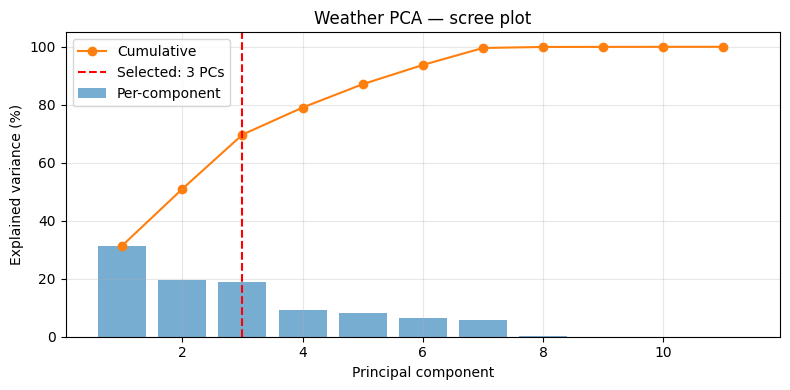

Weather PCA columns: ['weather_pc_1', 'weather_pc_2', 'weather_pc_3']
Explained variance ratio: [0.314 0.195 0.188]


In [13]:
def add_weather_pca(df, n_components=3):
    weather_cols = [
        c for c in [
            "temperature_f",
            "precipitation_in",
            "rain_in",
            "snowfall_in",
            "snow_depth_ft",
            "wind_speed_mph",
            "relative_humidity_pct",
            "dew_point_f",
            "apparent_temperature_f",
            "wind_gusts_mph",
            "wind_direction_deg",
            "cloud_cover_pct",
            "surface_pressure_hpa",
            "visibility_ft",
        ]
        if c in df.columns
    ]

    if len(weather_cols) < 2:
        print("Not enough weather columns for PCA. Skipping PCA.")
        return df, None, weather_cols

    weather_hourly = df[["hour"] + weather_cols].drop_duplicates(subset=["hour"]).sort_values("hour")
    X = weather_hourly[weather_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit full PCA first to produce the scree plot
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(X_scaled)

    fig, ax = plt.subplots(figsize=(8, 4))
    cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
    ax.bar(range(1, len(cumvar) + 1), pca_full.explained_variance_ratio_ * 100, alpha=0.6, label="Per-component")
    ax.plot(range(1, len(cumvar) + 1), cumvar, marker="o", color="tab:orange", label="Cumulative")
    ax.axvline(n_components, color="red", linestyle="--", label=f"Selected: {n_components} PCs")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance (%)")
    ax.set_title("Weather PCA — scree plot")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    n_components = min(n_components, len(weather_cols))
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(X_scaled)

    pc_cols = [f"weather_pc_{i+1}" for i in range(pcs.shape[1])]
    pc_df = pd.DataFrame(pcs, columns=pc_cols)
    pc_df["hour"] = weather_hourly["hour"].to_numpy()

    out = df.merge(pc_df, on="hour", how="left")
    return out, pca, weather_cols


weather_pca = None
weather_pca_cols = []
if USE_WEATHER_PCA:
    feature_df, weather_pca, weather_pca_cols = add_weather_pca(feature_df, n_components=N_WEATHER_PCS)

model_base_cache = OUTPUT_DIR / "feature_df_model_ready_2025_v5.parquet"
save_table_with_fallback(feature_df, model_base_cache)

pca_cols_present = [c for c in feature_df.columns if c.startswith("weather_pc_")]
print("Weather PCA columns:", pca_cols_present)
if weather_pca is not None:
    print("Explained variance ratio:", np.round(weather_pca.explained_variance_ratio_, 3))


## Exploratory analysis

Plots: hourly demand, weekday vs weekend, precipitation impact, monthly seasonality, busiest stations.

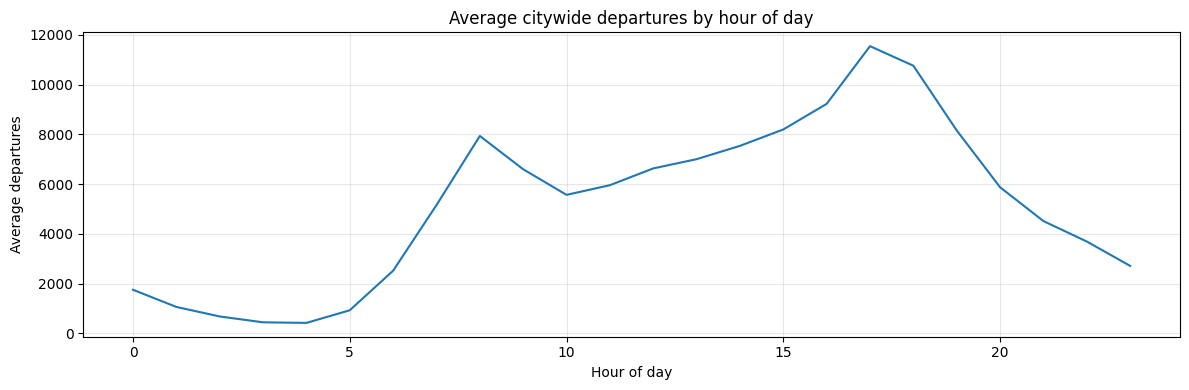

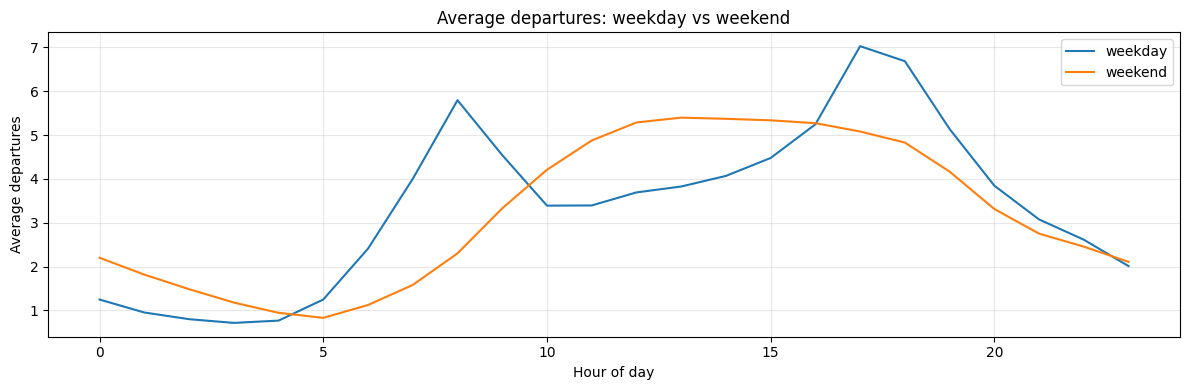

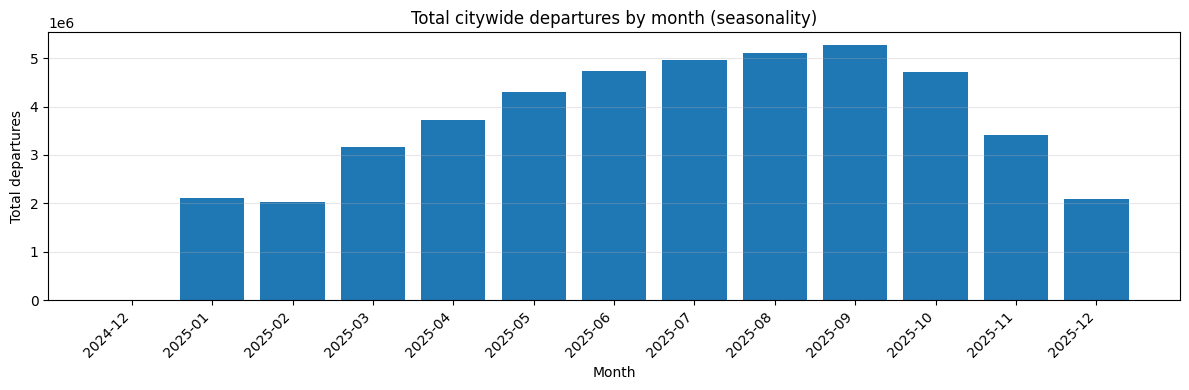

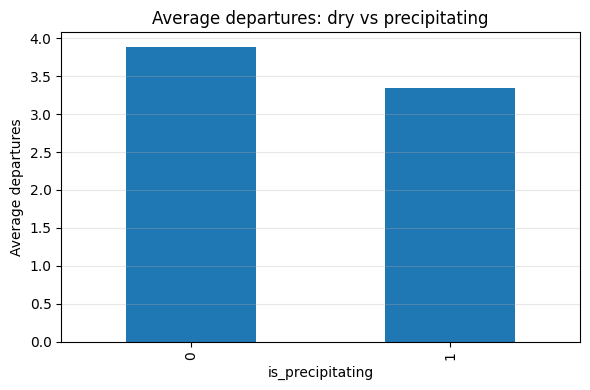

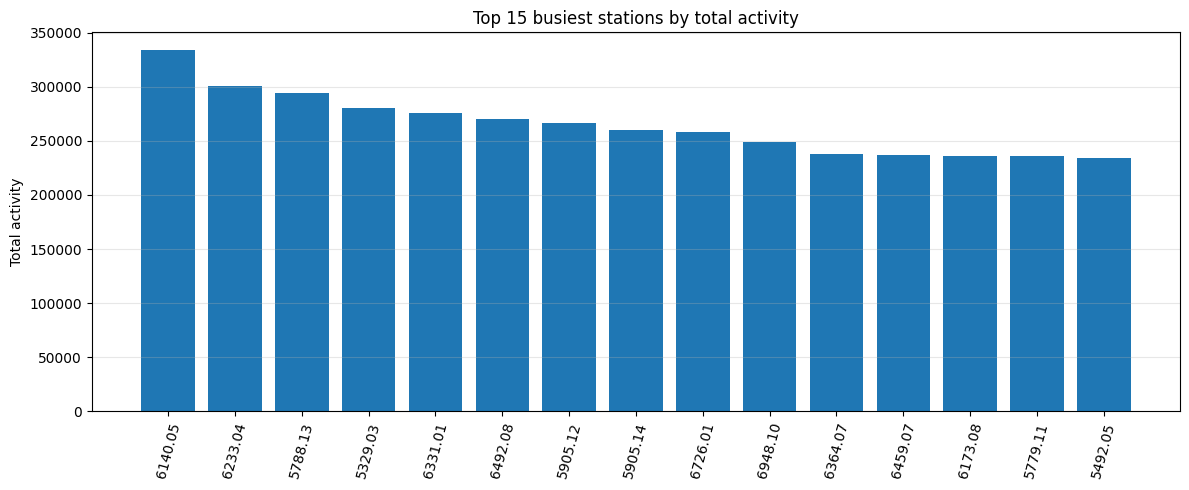

In [14]:
city_hour = (
    feature_df.groupby("hour", as_index=False)[["departures", "arrivals", "net_flow", "total_activity"]]
    .sum()
    .sort_values("hour")
)

# 1) Average citywide departures by hour of day
plt.figure(figsize=(12, 4))
city_hour.groupby(city_hour["hour"].dt.hour)["departures"].mean().plot()
plt.title("Average citywide departures by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Average departures")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Weekday vs weekend
weekday_weekend = (
    feature_df.groupby(["hour_of_day", "is_weekend"], as_index=False)["departures"]
    .mean()
    .pivot(index="hour_of_day", columns="is_weekend", values="departures")
)
weekday_weekend.columns = ["weekday" if c == 0 else "weekend" for c in weekday_weekend.columns]
weekday_weekend.plot(figsize=(12, 4))
plt.title("Average departures: weekday vs weekend")
plt.xlabel("Hour of day")
plt.ylabel("Average departures")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Monthly seasonality — total departures by month
monthly = (
    feature_df.assign(month_label=feature_df["hour"].dt.to_period("M").astype(str))
    .groupby("month_label", as_index=False)["departures"]
    .sum()
    .sort_values("month_label")
)
plt.figure(figsize=(12, 4))
plt.bar(monthly["month_label"], monthly["departures"])
plt.title("Total citywide departures by month (seasonality)")
plt.xlabel("Month")
plt.ylabel("Total departures")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Precipitation impact
if "is_precipitating" in feature_df.columns:
    rain_compare = feature_df.groupby("is_precipitating")["departures"].mean()
    plt.figure(figsize=(6, 4))
    rain_compare.plot(kind="bar")
    plt.title("Average departures: dry vs precipitating")
    plt.xlabel("is_precipitating")
    plt.ylabel("Average departures")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5) Busiest stations
busiest = (
    feature_df.groupby("station_key", as_index=False)["total_activity"]
    .sum()
    .sort_values("total_activity", ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 5))
plt.bar(busiest["station_key"].astype(str), busiest["total_activity"])
plt.title("Top 15 busiest stations by total activity")
plt.xticks(rotation=75)
plt.ylabel("Total activity")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Modeling helpers

This section fixes the biggest issue from the starter notebook:

- model selection happens on **validation**,
- the **test set is untouched** until the end,
- each target is evaluated separately,
- the best validation model for each target is retrained on **train + validation** before final test evaluation.


In [15]:

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        "rmse": rmse,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def chronological_split(model_df):
    model_df = model_df.sort_values("hour").reset_index(drop=True)
    unique_hours = np.sort(model_df["hour"].unique())
    if len(unique_hours) < 10:
        raise ValueError("Not enough hourly periods for a 70/15/15 chronological split.")

    train_idx = max(1, int(len(unique_hours) * 0.70))
    valid_idx = max(train_idx + 1, int(len(unique_hours) * 0.85))
    valid_idx = min(valid_idx, len(unique_hours) - 1)

    train_cutoff = unique_hours[train_idx]
    valid_cutoff = unique_hours[valid_idx]

    train_df = model_df.loc[model_df["hour"] < train_cutoff].copy()
    valid_df = model_df.loc[(model_df["hour"] >= train_cutoff) & (model_df["hour"] < valid_cutoff)].copy()
    test_df = model_df.loc[model_df["hour"] >= valid_cutoff].copy()
    return train_df, valid_df, test_df


def get_feature_columns(model_df, target_col):
    ordered_candidates = [
        "station_key",
        "station_cluster",
        "lat",
        "lng",
        # Cyclic time encodings (preferred over raw integer hour/dow)
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
        # Calendar flags (kept as-is for interpretability)
        "hour_of_day",
        "day_of_week",
        "month",
        "is_weekend",
        "is_holiday",
        "is_rush_hour",
        "is_commute_peak",
        "is_overnight",
        # Weather flags
        "is_precipitating",
        "is_raining",
        "is_snowing",
        "heavy_precip_flag",
        # NOTE: raw current-hour departures/arrivals/net_flow/total_activity are intentionally
        # excluded — only their lag/rolling versions are used so inference is unambiguous.
        "departures_lag_1",
        "departures_lag_2",
        "departures_lag_24",
        "arrivals_lag_1",
        "arrivals_lag_2",
        "arrivals_lag_24",
        "net_flow_lag_1",
        "net_flow_lag_2",
        "net_flow_lag_24",
        "total_activity_lag_1",
        "total_activity_lag_2",
        "total_activity_lag_24",
        "departures_roll_3",
        "departures_roll_24",
        "arrivals_roll_3",
        "arrivals_roll_24",
        "net_flow_roll_3",
        "net_flow_roll_24",
        "total_activity_roll_3",
        "total_activity_roll_3",
        "total_activity_roll_24",
        # Capacity features (from GBFS)
        "capacity",
        "is_active_station",
        "utilization_ratio_lag_1",
    ]


    ordered_candidates.extend([c for c in model_df.columns if c.startswith("weather_pc_")])
    feature_cols = [c for c in ordered_candidates if c in model_df.columns and c not in ["hour", target_col]]
    return list(dict.fromkeys(feature_cols))


def build_model_frame(df, target_col, top_n_stations=100):
    if target_col not in df.columns:
        raise ValueError(f"Target column not found: {target_col}")

    if "station_key" not in df.columns or "total_activity" not in df.columns:
        raise ValueError("Expected station_key and total_activity columns in feature_df.")

    # Identify the busiest stations without copying the full dataframe.
    busy_stations = (
        df.groupby("station_key", observed=True)["total_activity"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n_stations)
        .index
    )

    feature_cols = get_feature_columns(df, target_col)
    keep_cols = ["hour", target_col] + feature_cols
    keep_cols = [c for c in keep_cols if c in df.columns]

    mask = df["station_key"].isin(busy_stations) & df[target_col].notna()
    model_df = df.loc[mask, keep_cols].copy()

    for cat_col in ["station_key", "station_cluster"]:
        if cat_col in model_df.columns:
            model_df[cat_col] = model_df[cat_col].astype("category")

    return model_df


def build_estimator(model_name, numeric_features, categorical_features, random_state=42):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                categorical_features,
            ),
        ],
        remainder="drop",
    )

    if model_name == "Linear Regression":
        model = LinearRegression()
    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        )
    elif model_name == "Random Forest (deeper)":
        model = RandomForestRegressor(
            n_estimators=250,
            max_depth=18,
            min_samples_leaf=5,
            random_state=random_state,
            n_jobs=-1,
        )
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


def naive_predict(df, target_col, fallback_mean):
    # Use lag-1 (previous hour's actual) — avoids current-hour leakage.
    # At real inference time the current hour is incomplete, so lag_1 is the
    # cleanest "persistence" baseline.
    lag_map = {
        "departures_next_hour": "departures_lag_1",
        "arrivals_next_hour":   "arrivals_lag_1",
        "net_flow_next_hour":   "net_flow_lag_1",
    }
    lag_col = lag_map.get(target_col)
    if lag_col and lag_col in df.columns:
        return df[lag_col].fillna(fallback_mean).to_numpy()
    return np.repeat(fallback_mean, len(df))


def run_target_experiment(df, target_col, primary_label=False):
    model_df = build_model_frame(df, target_col, top_n_stations=TOP_N_STATIONS_FOR_MODEL)
    train_df, valid_df, test_df = chronological_split(model_df)

    feature_cols = [c for c in model_df.columns if c not in ["hour", target_col]]
    categorical_features = [c for c in ["station_key", "station_cluster"] if c in feature_cols]
    numeric_features = [c for c in feature_cols if c not in categorical_features]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)
    X_train_valid = train_valid_df[feature_cols]
    y_train_valid = train_valid_df[target_col]

    model_names = ["Naive baseline", "Linear Regression", "Random Forest", "Random Forest (deeper)"]

    validation_rows = []
    test_rows = []
    final_models = {}
    test_predictions = {}

    train_mean = float(y_train.mean())
    train_valid_mean = float(y_train_valid.mean())

    for model_name in model_names:
        if model_name == "Naive baseline":
            valid_pred = naive_predict(valid_df, target_col, fallback_mean=train_mean)
            test_pred = naive_predict(test_df, target_col, fallback_mean=train_valid_mean)
        else:
            estimator_valid = build_estimator(model_name, numeric_features, categorical_features, random_state=RANDOM_STATE)
            estimator_valid.fit(X_train, y_train)
            valid_pred = estimator_valid.predict(X_valid)
            del estimator_valid

            fitted_model = build_estimator(model_name, numeric_features, categorical_features, random_state=RANDOM_STATE)
            fitted_model.fit(X_train_valid, y_train_valid)
            test_pred = fitted_model.predict(X_test)
            final_models[model_name] = fitted_model

        valid_metrics = regression_metrics(y_valid, valid_pred)
        valid_metrics.update({"target": target_col, "model": model_name, "split": "validation"})
        validation_rows.append(valid_metrics)

        test_metrics = regression_metrics(y_test, test_pred)
        test_metrics.update({"target": target_col, "model": model_name, "split": "test"})
        test_rows.append(test_metrics)

        test_predictions[model_name] = test_pred

    validation_results = pd.DataFrame(validation_rows).sort_values("rmse").reset_index(drop=True)
    test_results = pd.DataFrame(test_rows).sort_values("rmse").reset_index(drop=True)
    best_model_name = validation_results.iloc[0]["model"]

    comparison = test_df[["hour", "station_key", target_col]].copy()
    for model_name, preds in test_predictions.items():
        safe_name = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        comparison[f"pred_{safe_name}"] = preds

    test_meta_cols = [c for c in ["hour", "station_key", "is_precipitating"] if c in test_df.columns]
    test_meta = test_df[test_meta_cols].copy()

    result = {
        "target": target_col,
        "validation_results": validation_results,
        "test_results": test_results,
        "best_model_name": best_model_name,
        "best_model": final_models.get(best_model_name),
        "comparison": comparison,
        "test_meta": test_meta,
        "feature_cols": feature_cols,
    }

    del model_df, train_df, valid_df, test_df, train_valid_df, X_train, X_valid, X_test, X_train_valid
    del y_train, y_valid, y_test, y_train_valid, test_predictions
    return result


def extract_feature_importance(fitted_pipeline):
    if fitted_pipeline is None:
        return None

    model = fitted_pipeline.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        return None

    preprocessor = fitted_pipeline.named_steps["preprocess"]
    feature_names = preprocessor.get_feature_names_out()
    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return importance_df


In [16]:

all_target_results = {}
summary_rows = []
primary_result = None

for target_col in TARGETS:
    result = run_target_experiment(feature_df, target_col, primary_label=(target_col == PRIMARY_TARGET))

    best_valid = result["validation_results"].iloc[0]
    best_test = result["test_results"].set_index("model").loc[best_valid["model"]]

    summary_rows.append({
        "target": target_col,
        "best_validation_model": best_valid["model"],
        "validation_rmse": best_valid["rmse"],
        "validation_mae": best_valid["mae"],
        "validation_r2": best_valid["r2"],
        "final_test_rmse": best_test["rmse"],
        "final_test_mae": best_test["mae"],
        "final_test_r2": best_test["r2"],
    })

    if target_col == PRIMARY_TARGET:
        primary_result = result
    else:
        all_target_results[target_col] = {
            "validation_results": result["validation_results"],
            "test_results": result["test_results"],
            "best_model_name": result["best_model_name"],
        }
        del result

if primary_result is not None:
    all_target_results[PRIMARY_TARGET] = primary_result

target_summary = pd.DataFrame(summary_rows).sort_values(["final_test_r2", "validation_r2"], ascending=False)
display(target_summary)


,target,best_validation_model,validation_rmse,validation_mae,validation_r2,final_test_rmse,final_test_mae,final_test_r2
0,departures_next_hour,Random Forest (deeper),6.882619,4.667609,0.806356,5.600449,3.978221,0.652992
1,arrivals_next_hour,Random Forest (deeper),7.010588,4.723236,0.798011,5.777604,4.033644,0.648003
2,net_flow_next_hour,Random Forest (deeper),6.707142,4.547096,0.482534,5.143539,3.519163,0.412881


In [17]:
primary_result = all_target_results[PRIMARY_TARGET]
print("Primary target:", PRIMARY_TARGET)
print("Best validation model:", primary_result["best_model_name"])

print("\nValidation results")
display(primary_result["validation_results"])

print("\nTest results")
display(primary_result["test_results"])

summary_path = OUTPUT_DIR / "target_summary_v4.csv"
validation_path = OUTPUT_DIR / f"validation_results_{PRIMARY_TARGET}_v4.csv"
test_path = OUTPUT_DIR / f"test_results_{PRIMARY_TARGET}_v4.csv"

target_summary.to_csv(summary_path, index=False)
primary_result["validation_results"].to_csv(validation_path, index=False)
primary_result["test_results"].to_csv(test_path, index=False)

print("Saved:")
print(summary_path)
print(validation_path)
print(test_path)


Primary target: departures_next_hour
Best validation model: Random Forest (deeper)

Validation results


,rmse,mae,r2,target,model,split
0,6.882619,4.667609,0.806356,departures_next_hour,Random Forest (deeper),validation
1,7.218676,4.882896,0.786985,departures_next_hour,Random Forest,validation
2,10.457788,7.209179,0.552930,departures_next_hour,Linear Regression,validation
3,15.187509,10.425838,0.057093,departures_next_hour,Naive baseline,validation



Test results


,rmse,mae,r2,target,model,split
0,5.600449,3.978221,0.652992,departures_next_hour,Random Forest (deeper),test
1,5.727912,4.095487,0.637017,departures_next_hour,Random Forest,test
2,7.680527,5.649192,0.347357,departures_next_hour,Linear Regression,test
3,8.942693,5.964109,0.115231,departures_next_hour,Naive baseline,test


Saved:
outputs\target_summary_v4.csv
outputs\validation_results_departures_next_hour_v4.csv
outputs\test_results_departures_next_hour_v4.csv


## Report-ready diagnostics for the primary target

Plots:
1. Predictions vs actuals — **two stations** (busiest commuter + highest leisure ratio).
2. Mean absolute error by hour of day.
3. **Residual histogram** and **Q-Q plot** for the best model.


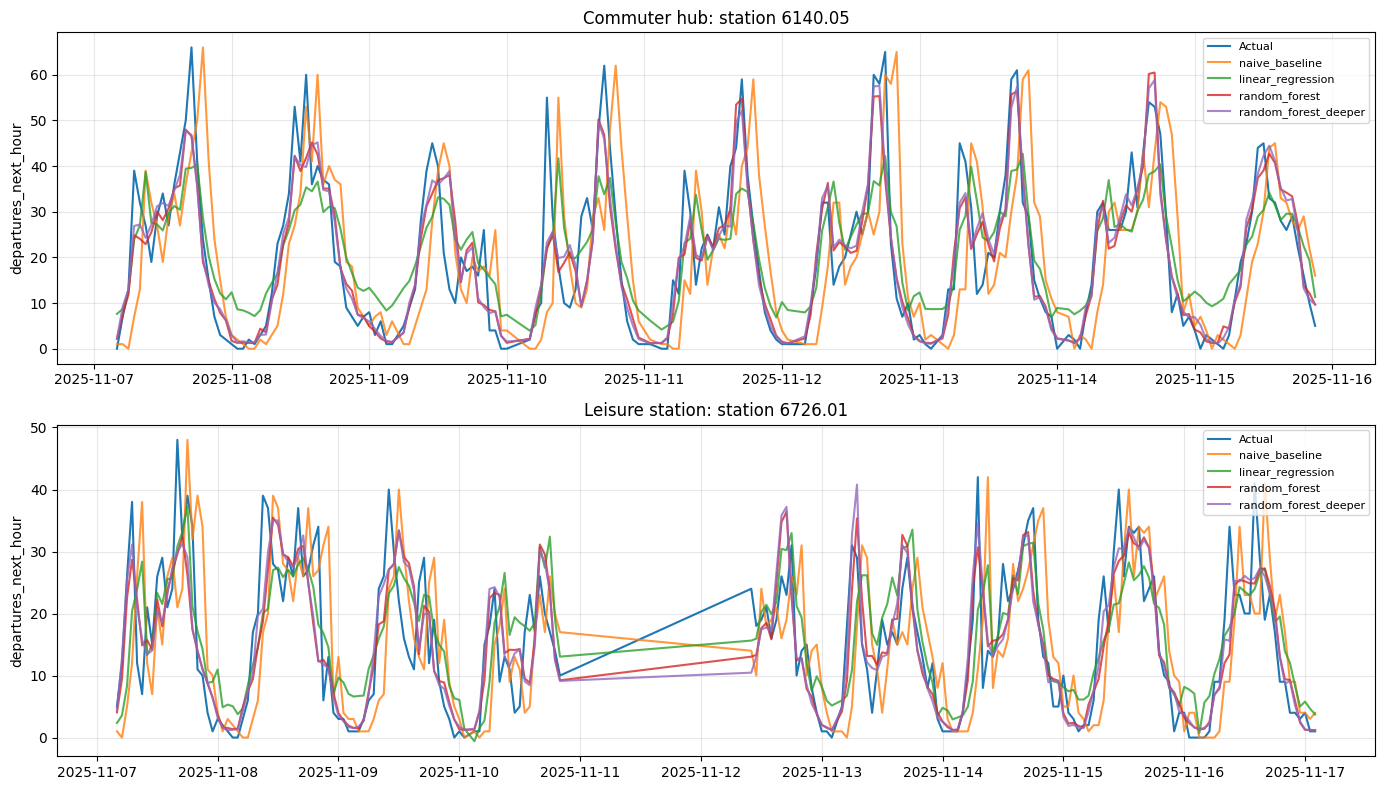

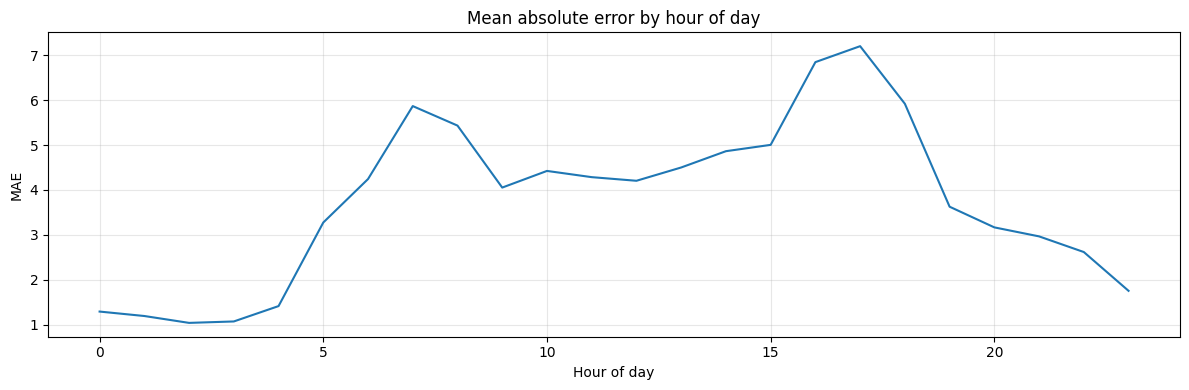

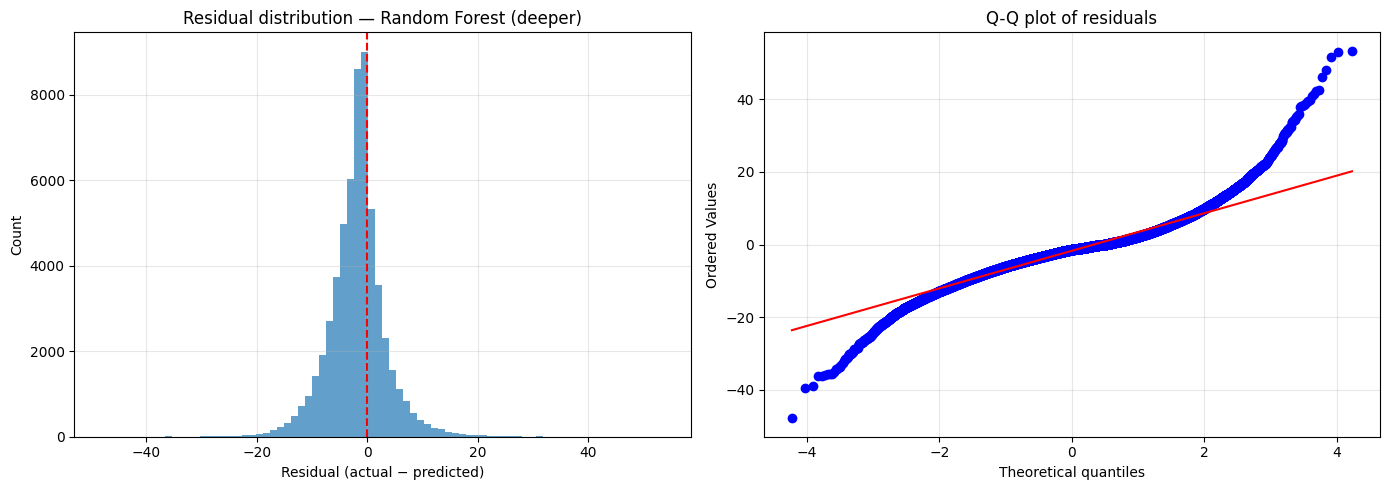

Residual mean: -1.716  |  std: 5.331  |  skew: 0.312


In [18]:
import scipy.stats as stats

comparison = primary_result["comparison"].copy()

best_col = "pred_" + primary_result["best_model_name"].lower().replace(" ", "_").replace("(", "").replace(")", "")

# --- Identify two representative stations ---
# Busiest overall (proxy for commuter hub)
station_activity = comparison.groupby("station_key")[PRIMARY_TARGET].sum().sort_values(ascending=False)
commuter_station = station_activity.index[0]

# Station with highest weekend share (proxy for leisure)
if "is_weekend" in primary_result.get("test_meta", pd.DataFrame()).columns:
    test_meta = primary_result["test_meta"]
    weekend_share = test_meta.groupby("station_key")["is_weekend"].mean()
    # Among top-50 by activity to avoid very quiet stations
    top50 = station_activity.head(50).index
    leisure_station = weekend_share.loc[weekend_share.index.isin(top50)].idxmax()
else:
    leisure_station = station_activity.index[min(10, len(station_activity) - 1)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, stn, label in zip(axes, [commuter_station, leisure_station], ["Commuter hub", "Leisure station"]):
    plot_df = comparison[comparison["station_key"] == stn].sort_values("hour").head(200)
    ax.plot(plot_df["hour"], plot_df[PRIMARY_TARGET], label="Actual")
    for col in [c for c in comparison.columns if c.startswith("pred_")]:
        ax.plot(plot_df["hour"], plot_df[col], label=col.replace("pred_", ""), alpha=0.8)
    ax.set_title(f"{label}: station {stn}")
    ax.set_ylabel(PRIMARY_TARGET)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- MAE by hour of day ---
error_df = comparison[["hour", PRIMARY_TARGET, best_col]].copy()
error_df["abs_error"] = (error_df[PRIMARY_TARGET] - error_df[best_col]).abs()
error_df["hour_of_day"] = error_df["hour"].dt.hour

hour_error = error_df.groupby("hour_of_day", as_index=False)["abs_error"].mean()
plt.figure(figsize=(12, 4))
plt.plot(hour_error["hour_of_day"], hour_error["abs_error"])
plt.title("Mean absolute error by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Residual distribution: histogram + Q-Q plot ---
residuals = (comparison[PRIMARY_TARGET] - comparison[best_col]).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(residuals, bins=80, edgecolor="none", alpha=0.7)
ax1.axvline(0, color="red", linestyle="--")
ax1.set_title(f"Residual distribution — {primary_result['best_model_name']}")
ax1.set_xlabel("Residual (actual − predicted)")
ax1.set_ylabel("Count")
ax1.grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title("Q-Q plot of residuals")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.3f}  |  std: {residuals.std():.3f}  |  skew: {residuals.skew():.3f}")


,is_precipitating,abs_error
0,0,3.947369
1,1,4.186016


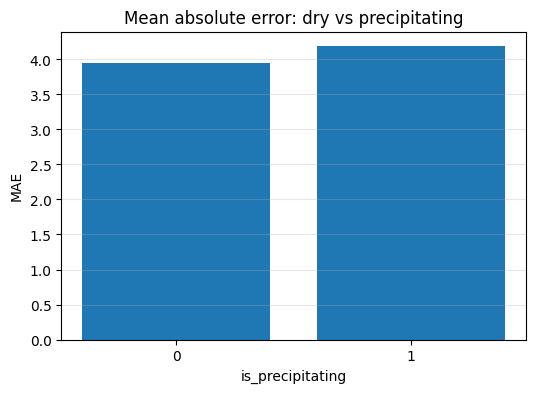

In [19]:

test_meta = primary_result.get("test_meta")
if test_meta is not None and "is_precipitating" in test_meta.columns:
    weather_error = test_meta[["hour", "station_key", "is_precipitating"]].copy().reset_index(drop=True)
    weather_error["abs_error"] = (comparison[PRIMARY_TARGET].reset_index(drop=True) - comparison[best_col].reset_index(drop=True)).abs()

    weather_summary = weather_error.groupby("is_precipitating", as_index=False)["abs_error"].mean()
    display(weather_summary)

    plt.figure(figsize=(6, 4))
    plt.bar(weather_summary["is_precipitating"].astype(str), weather_summary["abs_error"])
    plt.title("Mean absolute error: dry vs precipitating")
    plt.xlabel("is_precipitating")
    plt.ylabel("MAE")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


,feature,importance
0,num__total_activity_lag_1,0.359872
1,num__hour_cos,0.185749
2,num__hour_of_day,0.051251
3,num__departures_roll_24,0.051222
4,num__hour_sin,0.044715
5,num__arrivals_roll_24,0.040390
6,num__is_commute_peak,0.037121
7,num__total_activity_roll_24,0.017143
8,num__weather_pc_2,0.014951
9,num__dow_sin,0.013592


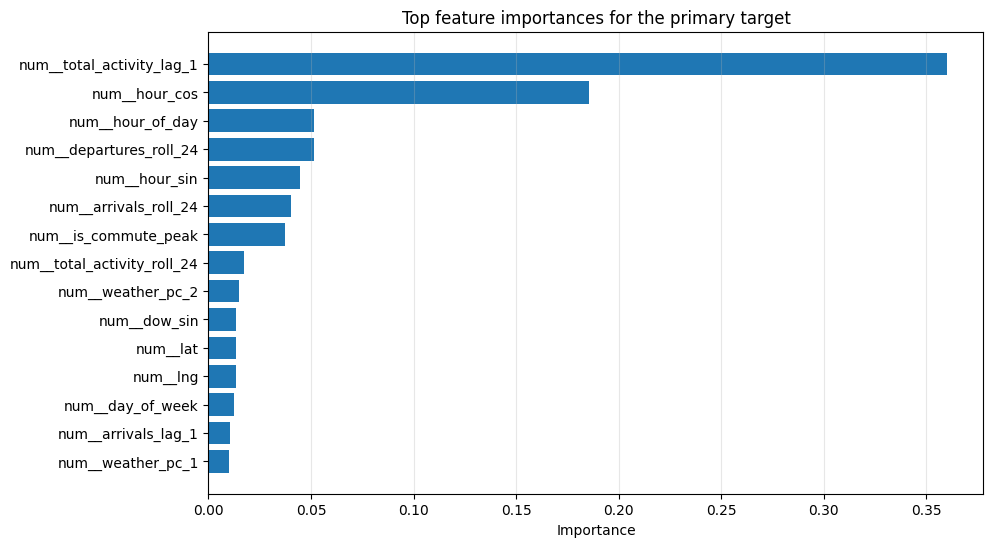

In [20]:
importance_df = extract_feature_importance(primary_result["best_model"])
if importance_df is None:
    print("Feature importance is only available for tree-based models. The selected primary model does not expose feature_importances_.")
else:
    display(importance_df.head(20))

    top_imp = importance_df.head(15).sort_values("importance")
    plt.figure(figsize=(10, 6))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title("Top feature importances for the primary target")
    plt.xlabel("Importance")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

    importance_df.to_csv(OUTPUT_DIR / f"feature_importance_{PRIMARY_TARGET}_v2.csv", index=False)


## What to write in the report after running this notebook

Use the outputs from this notebook to support these discussion points:

1. **Target comparison**
   Which is easier to predict: departures, arrivals, or net flow? Discuss why net flow is typically harder (it's a difference of two noisy signals).

2. **Validation vs test discipline**
   Model selection used validation only. The test set was evaluated exactly once.

3. **Cyclic time encoding**
   Explain why sin/cos of hour and day-of-week is better than raw integers — hour 23 should be "close to" hour 0.

4. **GBFS capacity and utilization**
   Explain that capacity came from the live GBFS feed (not historical). Acknowledge that station capacities may have changed during 2025. Describe the 50%-fill initialization assumption for utilization ratio and why it's a reasonable starting point.

5. **Station clustering**
   K-Means now includes capacity as a clustering feature, which cleanly separates large commuter hubs (Grand Central, Penn Station) from small neighborhood stations.

6. **Weather PCA**
   Reference the scree plot to justify N_WEATHER_PCS. Note what the first PC likely captures.

7. **Error analysis**
   Comment on: rush hour errors, precipitation errors, and the commuter vs leisure station error profile comparison.

8. **Residual diagnostics**
   Comment on whether residuals are symmetric or skewed. Right-skew (underestimating high demand) is the most common pattern and directly relevant to a rebalancing use case.

9. **Limitations**
   - GBFS capacity is current, not historical for all of 2025.
   - Utilization ratio uses a 50% fill initialization — the true starting fill is unknown.
   - Net flow proxy is an approximation; the system does true rebalancing via trucks between stations that is not captured.
